# Анализ задания 4

Цель: выбрать лучшего поставщика между `harpy.co` и `westeros.inc` на основе данных о производстве и дефектах

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("production-data.csv")

df["defects"] = df["defects"].clip(lower=0)
df["production.date"] = df["production.date"].astype(int)

df.head()

,unsullen.id,production.date,report.date,produced,defects,supplier
0,1.0,1,1,103.0,0.0,harpy.co
1,1.0,1,2,0.0,2.0,harpy.co
2,1.0,1,3,0.0,4.0,harpy.co
3,1.0,1,4,0.0,5.0,harpy.co
4,1.0,1,5,0.0,13.0,harpy.co


In [2]:
supplier_stats = (
    df.groupby("supplier", as_index=False)
      .agg(produced_total=("produced", "sum"), defects_total=("defects", "sum"))
)
supplier_stats["defect_rate"] = supplier_stats["defects_total"] / supplier_stats["produced_total"]
supplier_stats = supplier_stats.sort_values("defect_rate").reset_index(drop=True)

monthly_stats = (
    df.groupby(["supplier", "production.date"], as_index=False)
      .agg(produced_total=("produced", "sum"), defects_total=("defects", "sum"))
)
monthly_stats["defect_rate"] = monthly_stats["defects_total"] / monthly_stats["produced_total"]

supplier_stats

,supplier,produced_total,defects_total,defect_rate
0,harpy.co,31532.0,6080.0,0.19282
1,westeros.inc,31625.0,8269.0,0.26147


In [3]:
winner = supplier_stats.loc[0, "supplier"]

print("Отчет по качеству поставщиков:")

for row in supplier_stats.itertuples(index=False):
    print(
        f"- {row.supplier}: произведено={row.produced_total:.0f}, "
        f"дефектов={row.defects_total:.0f}, доля_дефектов={row.defect_rate:.4f}"
    )
    
print(f"\nРекомендуемый поставщик: {winner}")

Отчет по качеству поставщиков:
- harpy.co: произведено=31532, дефектов=6080, доля_дефектов=0.1928
- westeros.inc: произведено=31625, дефектов=8269, доля_дефектов=0.2615

Рекомендуемый поставщик: harpy.co


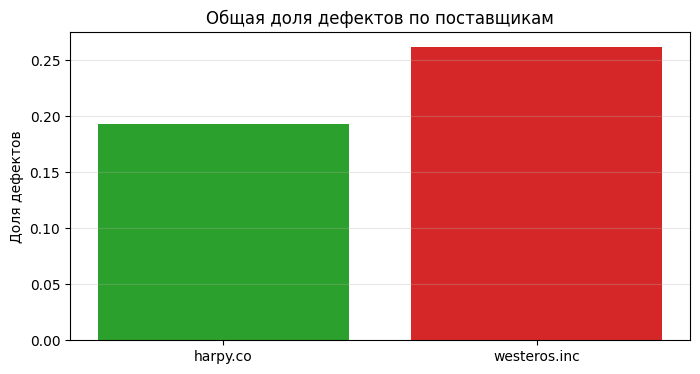

In [4]:
# Общая доля дефектов по поставщику

plt.figure(figsize=(8, 4))

colors = ["tab:green" if s == winner else "tab:red" for s in supplier_stats["supplier"]]

plt.bar(supplier_stats["supplier"], supplier_stats["defect_rate"], color=colors)
plt.ylabel("Доля дефектов")
plt.title("Общая доля дефектов по поставщикам")
plt.grid(axis="y", alpha=0.3)
plt.show()

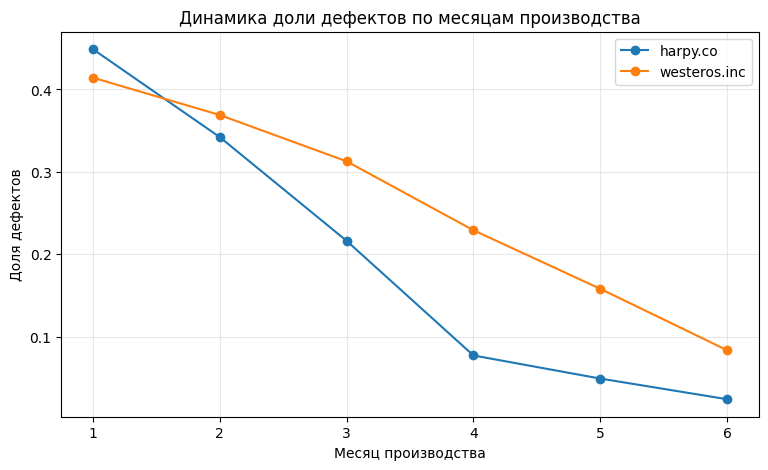

In [5]:
# Динамика доли дефектов по месяцу производства
plt.figure(figsize=(9, 5))
for supplier, group in monthly_stats.groupby("supplier"):
    group = group.sort_values("production.date")
    plt.plot(
        group["production.date"],
        group["defect_rate"],
        marker="o",
        label=supplier,
    )

plt.xlabel("Месяц производства")
plt.ylabel("Доля дефектов")
plt.title("Динамика доли дефектов по месяцам производства")
plt.xticks(sorted(monthly_stats["production.date"].unique()))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

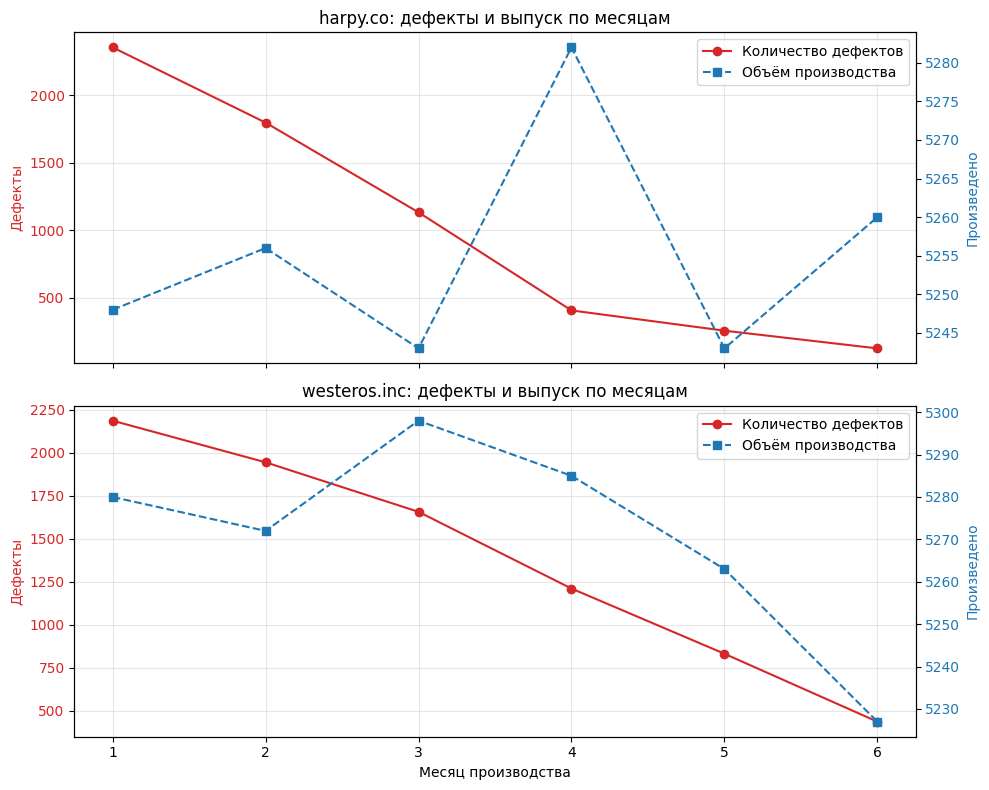

In [6]:
# По месяцам показываем и дефекты, и объём выпуска
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for ax, (supplier, group) in zip(axes, monthly_stats.groupby("supplier")):
    group = group.sort_values("production.date")

    # Левая ось: количество дефектов
    ax.plot(
        group["production.date"],
        group["defects_total"],
        marker="o",
        color="tab:red",
        label="Количество дефектов",
    )
    ax.set_ylabel("Дефекты", color="tab:red")
    ax.tick_params(axis="y", labelcolor="tab:red")
    ax.grid(alpha=0.3)

    # Правая ось: количество произведенной продукции
    ax2 = ax.twinx()
    ax2.plot(
        group["production.date"],
        group["produced_total"],
        marker="s",
        linestyle="--",
        color="tab:blue",
        label="Объём производства",
    )
    ax2.set_ylabel("Произведено", color="tab:blue")
    ax2.tick_params(axis="y", labelcolor="tab:blue")

    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc="upper right")

    ax.set_title(f"{supplier}: дефекты и выпуск по месяцам")

axes[-1].set_xlabel("Месяц производства")
plt.tight_layout()
plt.show()

In [7]:
print(f"Итоговая рекомендация по результатам EDA: {winner}")

Итоговая рекомендация по результатам EDA: harpy.co


In [8]:
# Дополнительные метрики: ранние поломки, тренд и стабильность относительно тренда
df_metrics = df.copy()
df_metrics["lag"] = df_metrics["report.date"] - df_metrics["production.date"]

early_defects = (
    df_metrics[df_metrics["lag"] <= 1]
    .groupby("supplier", as_index=False)
    .agg(early_defects=("defects", "sum"))
)

# Оценка тренда: defect_rate ~ a * month + b
# residual_std: стандартное отклонение остатков от тренда (чем меньше, тем стабильнее после учета тренда)
trend_rows = []
for supplier, group in monthly_stats.groupby("supplier"):
    group = group.sort_values("production.date")
    x = group["production.date"].to_numpy(dtype=float)
    y = group["defect_rate"].to_numpy(dtype=float)
    slope, intercept = np.polyfit(x, y, 1)
    y_hat = slope * x + intercept
    residual_std = float(np.std(y - y_hat, ddof=0))
    trend_rows.append(
        {
            "supplier": supplier,
            "trend_slope": float(slope),
            "residual_std": residual_std,
            "worst_monthly_defect_rate": float(np.max(y)),
            "last_month_rate": float(y[-1]),
        }
    )

trend_metrics = pd.DataFrame(trend_rows)

extra_metrics = supplier_stats[["supplier", "produced_total", "defect_rate"]].merge(
    early_defects, on="supplier", how="left"
).merge(
    trend_metrics, on="supplier", how="left"
)

extra_metrics["early_failure_rate"] = extra_metrics["early_defects"] / extra_metrics["produced_total"]
extra_metrics = extra_metrics[[
    "supplier",
    "defect_rate",
    "early_failure_rate",
    "trend_slope",
    "residual_std",
    "last_month_rate",
    "worst_monthly_defect_rate",
]].sort_values("defect_rate")

extra_metrics

,supplier,defect_rate,early_failure_rate,trend_slope,residual_std,last_month_rate,worst_monthly_defect_rate
0,harpy.co,0.19282,0.024768,-0.089733,0.040517,0.024144,0.448742
1,westeros.inc,0.26147,0.084838,-0.067690,0.010732,0.083604,0.414205


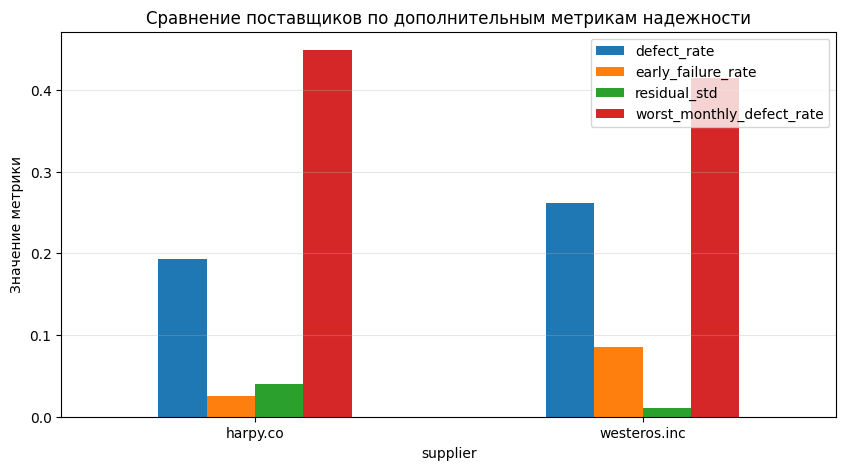

In [9]:
# Сравнение дополнительных метрик надежности.
plot_metrics = extra_metrics.set_index("supplier")[[
    "defect_rate",
    "early_failure_rate",
    "residual_std",
    "worst_monthly_defect_rate",
]]

ax = plot_metrics.plot(kind="bar", figsize=(10, 5))
ax.set_title("Сравнение поставщиков по дополнительным метрикам надежности")
ax.set_ylabel("Значение метрики")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.legend(loc="best")
plt.show()

In [10]:
best = extra_metrics.sort_values(
    ["defect_rate", "early_failure_rate", "residual_std", "trend_slope"]
).iloc[0]

print("Рекомендация с учетом дополнительных метрик:")
print(
    f"- поставщик={best['supplier']}, "
    f"общая_доля={best['defect_rate']:.4f}, "
    f"ранняя_доля={best['early_failure_rate']:.4f}, "
    f"наклон_тренда={best['trend_slope']:.4f}, "
    f"остаточная_нестабильность={best['residual_std']:.4f}, "
    f"последний_месяц={best['last_month_rate']:.4f}, "
    f"худший_месяц={best['worst_monthly_defect_rate']:.4f}"
)

Рекомендация с учетом дополнительных метрик:
- поставщик=harpy.co, общая_доля=0.1928, ранняя_доля=0.0248, наклон_тренда=-0.0897, остаточная_нестабильность=0.0405, последний_месяц=0.0241, худший_месяц=0.4487
